# TOBB ETÜ Yapay Zeka Mühendisliği Bölümü
### YAP 470 / BİL 570 Dönem Projesi 3. Ara Rapor

##### İlbey Efe Taşabatlı
##### 221101026
##### YAP470

# Yüz İfadelerinin Sınıflandırılması ve Gerçek Zamanlı Tahmini

**Açıklama:**
Bu rapor, 'FANE: Facial Expressions & Emotion Dataset' (Kaggle) kullanarak yüz ifadelerini sınıflandırma projesinin
3. Ara Raporudur. Projede uygulanan detaylı Veri Keşfi ve Analizi (EDA), veri ön işleme,
SVM, Boosting ve MLP algoritmaları sunulmuştur.

EK: Şu noktada MLP ile başarılı sonuç alınamadığı için ek olarak RandomForest Metodu Eklenmiştir.

### Import Statements

In [ ]:
import os
import subprocess
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

import cv2
import dlib
from skimage.feature import hog
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import xgboost as xgb

### Deciding Optimal Input Size

In [ ]:

# Gerekli fonksiyonları ve dlib dedektörünü hazırlama
print("Fonksiyonlar ve dlib dedektörü hazırlanıyor...")
face_detector = dlib.get_frontal_face_detector()

def process_and_save_image(input_path, output_path, target_size):
    try:
        img = cv2.imread(str(input_path))
        if img is None: return False

        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        rects = face_detector(rgb, 1)
        if not rects: return False

        rect = rects[0]
        x1, y1, x2, y2 = rect.left(), rect.top(), rect.right(), rect.bottom()

        w, h = x2 - x1, y2 - y1
        cx, cy = x1 + w // 2, y1 + h // 2
        new_w, new_h = int(w * 1.5), int(h * 1.5)
        nx1, ny1 = max(cx - new_w // 2, 0), max(cy - new_h // 2, 0)
        nx2, ny2 = min(cx + new_w // 2, img.shape[1]), min(cy + new_h // 2, img.shape[0])
        
        face_crop = img[ny1:ny2, nx1:nx2]
        if face_crop.size == 0: return False

        img_yuv = cv2.cvtColor(face_crop, cv2.COLOR_BGR2YUV)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
        face_crop_clahe = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

        h_crop, w_crop = face_crop_clahe.shape[:2]
        scale = target_size / max(h_crop, w_crop)
        resized = cv2.resize(face_crop_clahe, (int(w_crop * scale), int(h_crop * scale)))

        final_img = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        canvas = np.zeros((target_size, target_size), dtype=np.uint8)
        y_off = (target_size - final_img.shape[0]) // 2
        x_off = (target_size - final_img.shape[1]) // 2
        canvas[y_off:y_off + final_img.shape[0], x_off:x_off + final_img.shape[1]] = final_img

        os.makedirs(output_path.parent, exist_ok=True)
        cv2.imwrite(str(output_path), canvas)
        return True
    except Exception as e:
        return False

# Deney ayarları
print("Deney ayarları yapılıyor...")
TARGET_SIZES_TO_TEST = [64, 96, 128, 160]
DATA_SUBSET_FRACTION = 0.20
INPUT_FOLDER_NAME = "fane_data"

BASE_DIR = Path().resolve()
INPUT_DATA_PATH = BASE_DIR / INPUT_FOLDER_NAME

size_experiment_results = []
image_extensions = [".jpg", ".jpeg", ".png"]

# Deney süreci
all_raw_images = [p for p in INPUT_DATA_PATH.rglob("*") if p.suffix.lower() in image_extensions]

if not all_raw_images:
    print(f"HATA: '{INPUT_DATA_PATH}' klasöründe resim bulunamadı.")
else:
    for target_size in TARGET_SIZES_TO_TEST:
        print(f"\n----- BOYUT TESTİ: {target_size}x{target_size} -----")
        
        start_time_total = time.time()
        temp_output_path = BASE_DIR / f'temp_processed_{target_size}'
        
        try:
            print(f"  > Adım 1: Resimler işleniyor...")
            for img_path in tqdm(all_raw_images, desc=f"İşleme ({target_size}x{target_size})", leave=False, bar_format='{l_bar}{bar:20}{r_bar}'):
                rel_path = img_path.relative_to(INPUT_DATA_PATH)
                out_path = temp_output_path / rel_path.with_suffix('.png')
                process_and_save_image(img_path, out_path, target_size)

            print(f"  > Adım 2: HOG özellikleri çıkarılıyor...")
            features_list, labels_list = [], []
            
            processed_files_with_labels = []
            for class_dir in temp_output_path.iterdir():
                if class_dir.is_dir():
                    for img_file in class_dir.glob('*.png'):
                        processed_files_with_labels.append((img_file, class_dir.name))
            
            if not processed_files_with_labels:
                print("  > Hata: İşlenmiş dosya bulunamadı. Bu boyut atlanıyor.")
                continue

            _, subset_files = train_test_split(
                processed_files_with_labels, 
                test_size=DATA_SUBSET_FRACTION, 
                stratify=[f[1] for f in processed_files_with_labels], 
                random_state=42
            )
            
            for img_path, label in tqdm(subset_files, desc="HOG Çıkarma", leave=False, bar_format='{l_bar}{bar:20}{r_bar}'):
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    hog_features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                                       cells_per_block=(2, 2), visualize=False)
                    features_list.append(hog_features)
                    labels_list.append(label)

            X_subset, y_subset = np.array(features_list), np.array(labels_list)
            
            if X_subset.shape[0] == 0:
                print("  > Hata: Özellik çıkarılamadı. Bu boyut atlanıyor.")
                continue

            print(f"  > Adım 3: SVM modeli eğitiliyor...")
            X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
                X_subset, y_subset, test_size=0.25, random_state=42, stratify=y_subset
            )
            
            pipe_fast_svm = Pipeline([
                ('scaler', StandardScaler()),
                ('svm', SVC(C=1, gamma='scale', random_state=42))
            ])
            
            pipe_fast_svm.fit(X_train_exp, y_train_exp)
            y_pred_exp = pipe_fast_svm.predict(X_test_exp)
            accuracy = accuracy_score(y_test_exp, y_pred_exp)
            
            total_duration = time.time() - start_time_total
            
            size_experiment_results.append({
                'Boyut': f"{target_size}x{target_size}",
                'Doğruluk': round(accuracy, 4),
                'Toplam Süre (s)': round(total_duration, 2),
                'HOG Vektör Boyutu': X_subset.shape[1]
            })
            print(f"  > Sonuç: Doğruluk={accuracy:.4f} | Süre={total_duration:.2f}s | HOG Boyutu={X_subset.shape[1]}")

        finally:
            if temp_output_path.exists():
                shutil.rmtree(temp_output_path)

# Sonuç raporu
print("\n" + "="*50)
print("Optimal Boyut Deneyi Sonuçları")
print("="*50)

if size_experiment_results:
    df_results = pd.DataFrame(size_experiment_results)
    print(df_results.to_string(index=False))
    
    best_row = df_results.loc[df_results['Doğruluk'].idxmax()]
    OPTIMAL_TARGET_SIZE = int(best_row['Boyut'].split('x')[0])
    
    print(f"\nKarar: En iyi performansı {best_row['Doğruluk']} doğruluğu ile {OPTIMAL_TARGET_SIZE}x{OPTIMAL_TARGET_SIZE} boyutu verdi.")
    print("Projenin geri kalanında bu boyut kullanılacak.")
else:
    print("Deney tamamlanamadı. Varsayılan olarak 96x96 kullanılacak.")
    OPTIMAL_TARGET_SIZE = 96

Gerekli fonksiyonlar ve dlib dedektörü hazırlanıyor...
Deney konfigürasyonu ayarlanıyor...

DENEY BAŞLIYOR: BOYUT = 64x64
  > Adım 1: Resimler ön işleniyor...


  > Adım 2: HOG öznitelikleri çıkarılıyor...


  > Adım 3: Basit bir SVM modeli eğitiliyor...
  > Sonuç: Doğruluk=0.3441, Süre=272.34s, HOG Boyutu=1764
  > Geçici klasör 'temp_processed_64' temizleniyor...

DENEY BAŞLIYOR: BOYUT = 96x96
  > Adım 1: Resimler ön işleniyor...


  > Adım 2: HOG öznitelikleri çıkarılıyor...


  > Adım 3: Basit bir SVM modeli eğitiliyor...
  > Sonuç: Doğruluk=0.3697, Süre=271.42s, HOG Boyutu=4356
  > Geçici klasör 'temp_processed_96' temizleniyor...

DENEY BAŞLIYOR: BOYUT = 128x128
  > Adım 1: Resimler ön işleniyor...


  > Adım 2: HOG öznitelikleri çıkarılıyor...


  > Adım 3: Basit bir SVM modeli eğitiliyor...
  > Sonuç: Doğruluk=0.3816, Süre=286.20s, HOG Boyutu=8100
  > Geçici klasör 'temp_processed_128' temizleniyor...

DENEY BAŞLIYOR: BOYUT = 160x160
  > Adım 1: Resimler ön işleniyor...


  > Adım 2: HOG öznitelikleri çıkarılıyor...


  > Adım 3: Basit bir SVM modeli eğitiliyor...
  > Sonuç: Doğruluk=0.3629, Süre=720.43s, HOG Boyutu=12996
  > Geçici klasör 'temp_processed_160' temizleniyor...

Optimal Boyut Deneyi Sonuç Raporu
Farklı girdi boyutlarının model performansı ve verimliliği üzerindeki etkisi:
  Boyut  Doğruluk  Toplam Süre (s)  HOG Vektör Boyutu
  64x64    0.3441           272.34               1764
  96x96    0.3697           271.42               4356
128x128    0.3816           286.20               8100
160x160    0.3629           720.43              12996

Analiz Sonucu: En yüksek doğruluğu (0.3816) veren ve makul bir sürede çalışan
en uygun boyut olarak **128x128** seçilmiştir.
Projenin geri kalanında bu boyut kullanılacaktır.


### Preprocessing

In [ ]:

BASE_DIR = Path().resolve()

ORIGINAL_DATASET_PATH = BASE_DIR / 'fane_data'
PROCESSED_DATASET_PATH = BASE_DIR / 'processed_dataset_gray'
PREPROCESSING_SCRIPT_PATH = BASE_DIR / 'preprocess.py'
IMG_SIZE = (128, 128)


IS_PROCESSED_AVAILABLE = False
CLASS_NAMES = []

try:
    CLASS_NAMES = sorted([d for d in os.listdir(ORIGINAL_DATASET_PATH) if os.path.isdir(os.path.join(ORIGINAL_DATASET_PATH, d))])
    if CLASS_NAMES:
        print(f"{len(CLASS_NAMES)} classes found: {CLASS_NAMES}")
except FileNotFoundError:
    print(f"Error: Original dataset not found at {ORIGINAL_DATASET_PATH}")
    CLASS_NAMES = []

# preprocess check
print("\nStep 1: Checking preprocessing status")

if not PROCESSED_DATASET_PATH.exists() or not any(PROCESSED_DATASET_PATH.iterdir()):
    print(f"Processed dataset not found at '{PROCESSED_DATASET_PATH}'. Running preprocessing script...")

    if not Path(PREPROCESSING_SCRIPT_PATH).exists():
        print(f"Error: Script '{PREPROCESSING_SCRIPT_PATH}' not found.")
    else:
        try:
            result = subprocess.run(
                ['python', str(PREPROCESSING_SCRIPT_PATH)], 
                capture_output=True, 
                text=True, 
                check=True
            )
            print("Preprocessing completed successfully.")
            print(result.stdout)
            IS_PROCESSED_AVAILABLE = True
        except FileNotFoundError:
            print("Error: 'python' command not found. Is Python in your system's PATH?")
        except subprocess.CalledProcessError as e:
            print("Error while running preprocessing script:")
            print(e.stderr)
        except Exception as e:
            print(f"An unexpected error occurred: {e}")
else:
    print("Processed dataset already exists. Skipping preprocessing.")
    IS_PROCESSED_AVAILABLE = True

# extract HOG
print("\nStep 2: Extracting HOG Features and Assembling Data")

features_list = []
labels_list = []
X, y = (np.array([]), np.array([]))

if IS_PROCESSED_AVAILABLE and CLASS_NAMES:
    image_extensions = ['*.png', '*.jpg', '*.jpeg']
    
    for class_name in CLASS_NAMES:
        class_path = PROCESSED_DATASET_PATH / class_name
        if class_path.is_dir():
            all_image_paths = []
            for ext in image_extensions:
                all_image_paths.extend(class_path.glob(ext))
            
            # Now loop through the found image paths
            for img_path in tqdm(sorted(all_image_paths), desc=f"Processing {class_name}"):
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is not None and img.shape == IMG_SIZE:
                    hog_features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                                       cells_per_block=(2, 2), visualize=False, block_norm='L2-Hys')
                    features_list.append(hog_features)
                    labels_list.append(class_name)

    if features_list:
        X = np.array(features_list)
        y = np.array(labels_list)
        print(f"\nSuccessfully created Feature Matrix X with shape: {X.shape}")
        print(f"Successfully created Label Vector y with shape: {y.shape}")
    else:
        print("\nWarning: No features were extracted. Please check the 'processed_dataset_gray' folder and its contents.")
else:
    print("Error: Cannot proceed with feature extraction. Processed data is not available.")

#splitting
print("\nStep 3: Splitting the dataset")

X_train, X_test, y_train, y_test = (np.array([]), np.array([]), np.array([]), np.array([]))

if X.size > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, shuffle=True, random_state=42, stratify=y
    )

    print(f"Training set samples: {X_train.shape[0]}")
    print(f"Testing set samples: {X_test.shape[0]}")
else:
    print("Error: Feature matrix X is empty. Cannot split data.")

print("\n--- DATA PREPARATION COMPLETE ---")
print("The following variables are ready for model training:")
print("X_train, y_train, X_test, y_test")

9 classes found: ['angry', 'confused', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'shy', 'surprise']

Step 1: Checking preprocessing status
Processed dataset already exists. Skipping preprocessing.

Step 2: Extracting HOG Features and Assembling Data


Processing surprise: 100%|██████████| 1417/1417 [00:08<00:00, 166.35it/s]



Successfully created Feature Matrix X with shape: (11740, 8100)
Successfully created Label Vector y with shape: (11740,)

Step 3: Splitting the dataset
Training set samples: 8805
Testing set samples: 2935

--- DATA PREPARATION COMPLETE ---
The following variables are ready for model training:
X_train, y_train, X_test, y_test


# Exploratory Data Analysis (EDA)


BÖLÜM A: Karşılaştırmalı EDA - DETAYLI HATA AYIKLAMA
Orijinal Veri Yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\fane_data
İşlenmiş Veri Yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\processed_dataset_gray
Orijinal Yol Mevcut mu? -> True
İşlenmiş Yol Mevcut mu? -> True

Örnek Sınıfın Orijinal Yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\fane_data\happy
Örnek Sınıfın İşlenmiş Yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\processed_dataset_gray\happy

Başarıyla 3 adet örnek dosya adı seçildi: ['happy1710.jpg' 'happy639.jpg' 'happy975.jpg']
--------------------------------------------------
İşleniyor: happy1710.jpg
  -> 'Önce' için aranan yol: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\fane_data\happy\happy1710.jpg
  -> 'Önce' resmi başarıyla okundu.
  -> 'Sonra' için aranan yol: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\processed_dataset_gray\happy\happy1

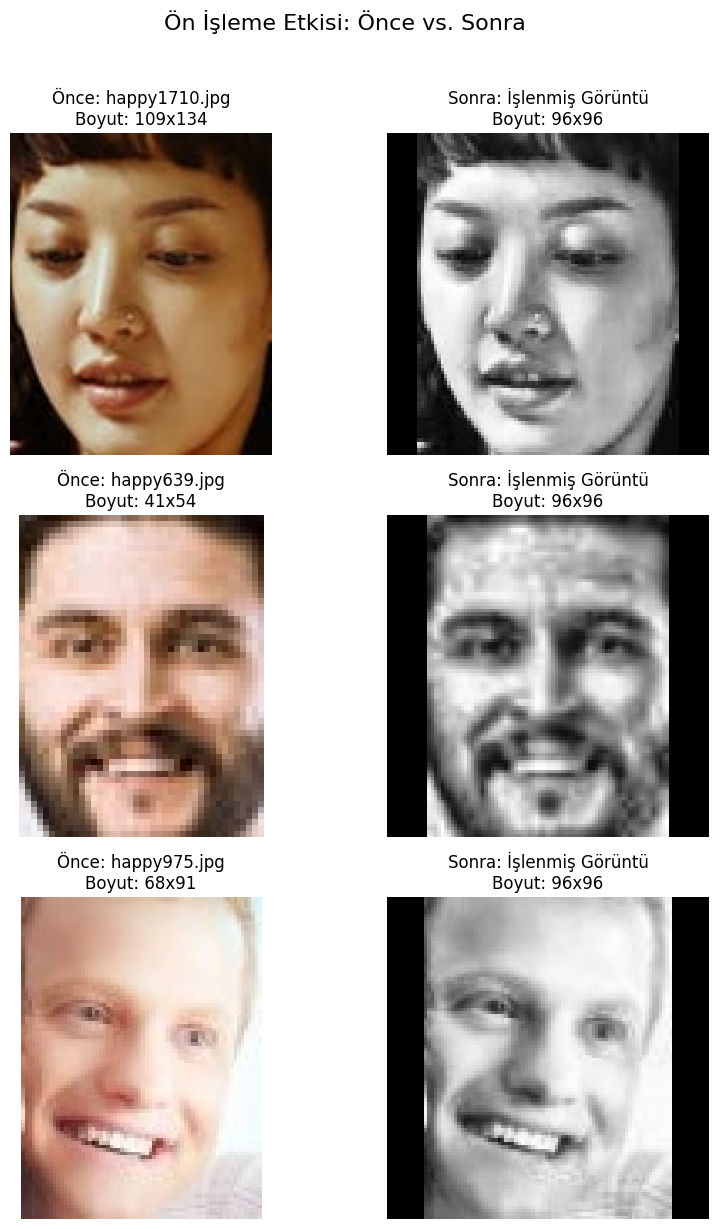


BÖLUM B: EDA on HOG Features & Class Labels

--- B.1. Class Distribution (Training Set) ---
Class Distribution Table:
 Emotion  Count  Percentage (%)
   angry    907           10.30
confused    733            8.32
 disgust    737            8.37
    fear   1455           16.52
   happy    956           10.86
 neutral   1142           12.97
     sad   1333           15.14
     shy    479            5.44
surprise   1063           12.07


C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_16788\3353825317.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, order=df_counts['Emotion'], palette='viridis')


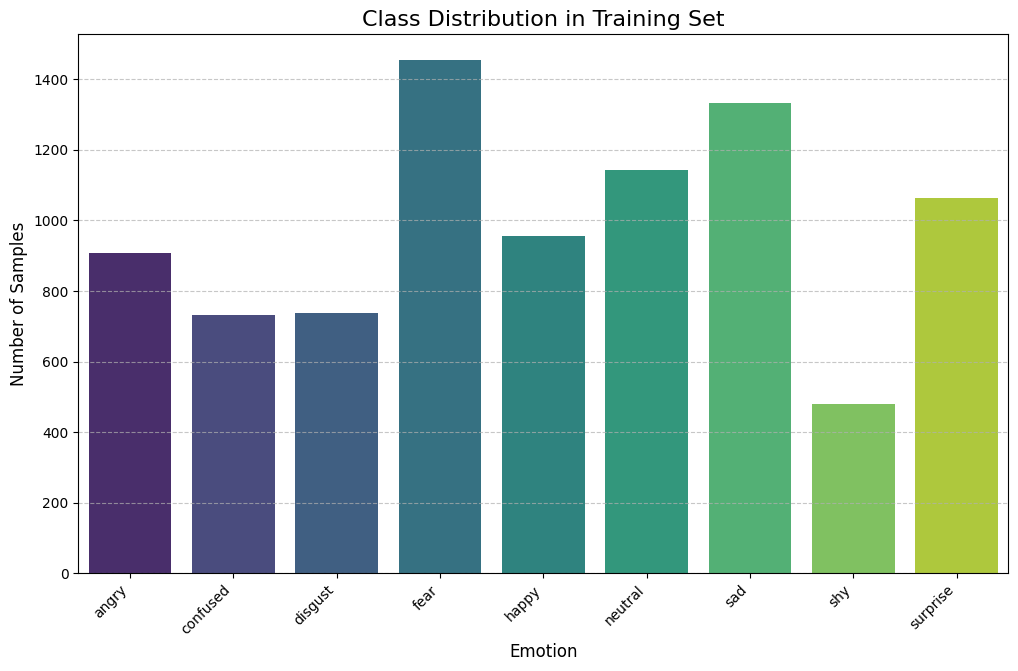


--- B.2. HOG Feature Statistics ---
Descriptive Statistics for the first 10 HOG features:
    count      mean       std  min       25%       50%       75%       max
0  8805.0  0.043372  0.107782  0.0  0.002224  0.003883  0.006876  0.657067
1  8805.0  0.004699  0.029025  0.0  0.000000  0.000000  0.000000  0.350187
2  8805.0  0.002790  0.020942  0.0  0.000000  0.000000  0.000000  0.396697
3  8805.0  0.001599  0.014349  0.0  0.000000  0.000000  0.000000  0.396697
4  8805.0  0.002564  0.021503  0.0  0.000000  0.000000  0.000000  0.521729
5  8805.0  0.001432  0.013299  0.0  0.000000  0.000000  0.000000  0.457539
6  8805.0  0.001613  0.012643  0.0  0.000000  0.000000  0.000000  0.238434
7  8805.0  0.002832  0.019884  0.0  0.000000  0.000000  0.000000  0.327049
8  8805.0  0.013018  0.059818  0.0  0.000000  0.000000  0.000000  0.542299
9  8805.0  0.408515  0.085308  0.0  0.362838  0.409717  0.460261  0.745356

Summary: The full HOG feature set contains 4356 features.
The mean value across all

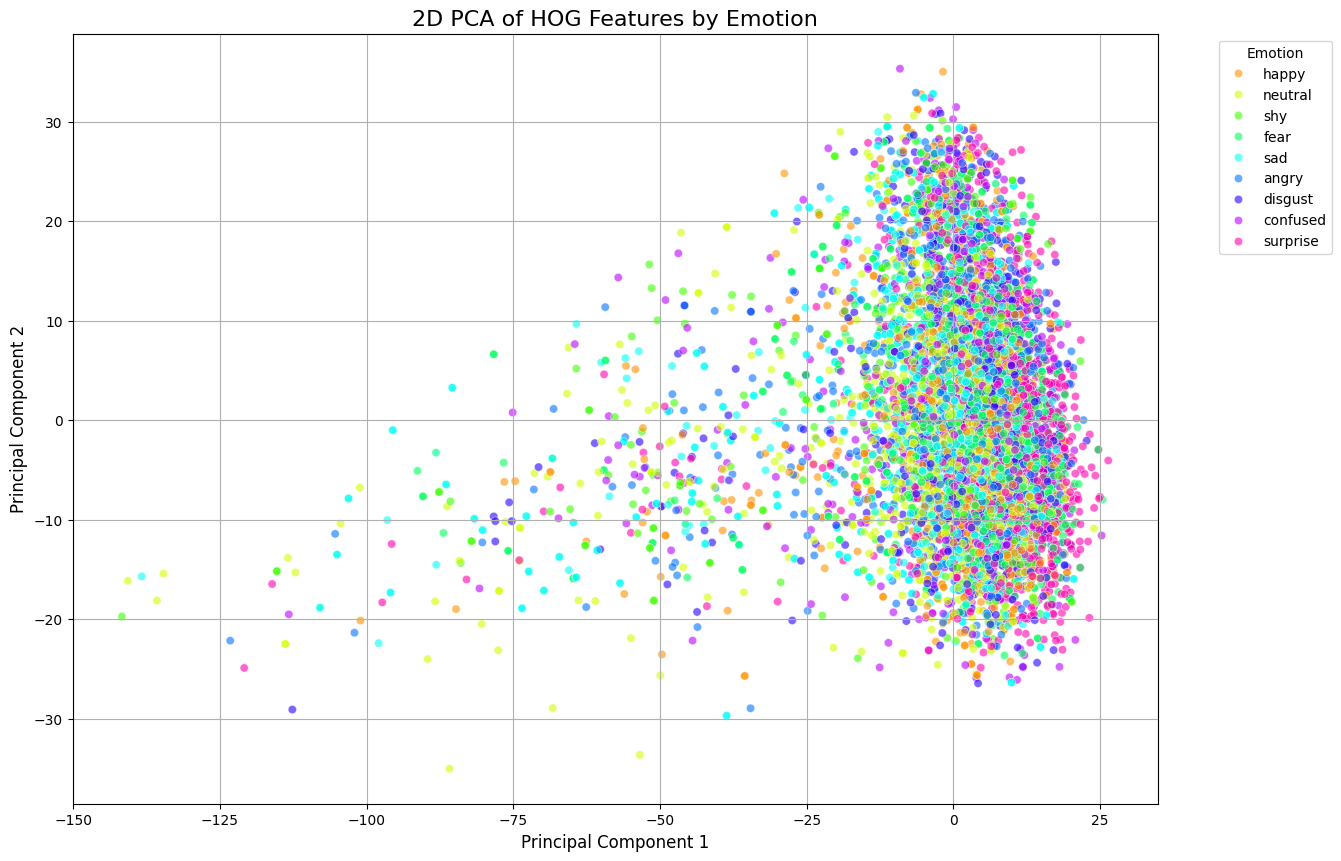


--- B.4. PCA Explained Variance Analysis ---
Number of PCA components needed to capture variance:
Variance Explained  Components Needed
               80%                455
               90%                737
               95%                971
               99%               1668


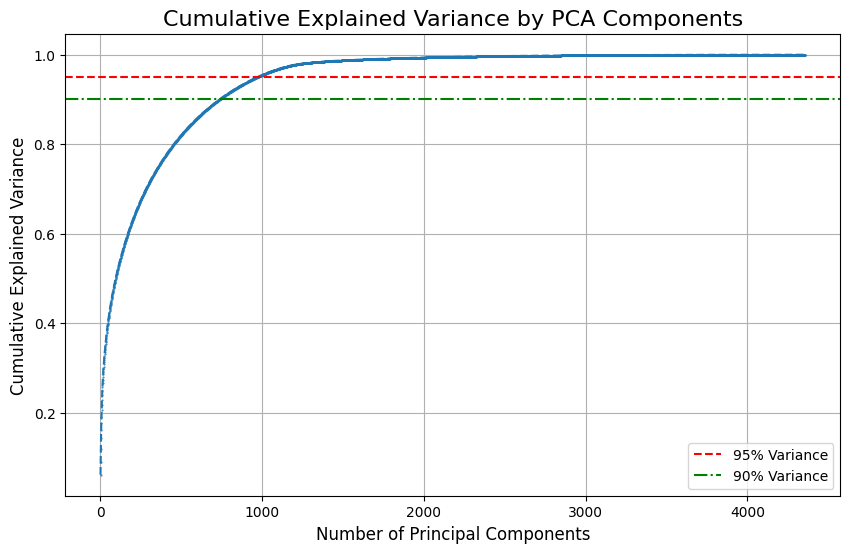


BÖLÜM C: Derinlemesine EDA: Sınıf Bazında Analiz ve Gelişmiş Görselleştirme

--- C.1. Sınıf Bazında Ortalama Öznitelik Değerleri ---
Her Duygu İçin İlk 5 HOG Özniteliğinin Ortalama Değerleri:
                 0         1         2         3         4
Emotion                                                   
angry     0.039989  0.002889  0.001758  0.000740  0.002088
confused  0.058251  0.003451  0.002390  0.001318  0.001381
disgust   0.041562  0.003076  0.002860  0.001903  0.001859
fear      0.024356  0.002046  0.001167  0.000736  0.001358
happy     0.042954  0.003654  0.001374  0.000739  0.001082
neutral   0.054206  0.008590  0.003969  0.003082  0.004105
sad       0.056044  0.008038  0.005592  0.002332  0.004378
shy       0.074034  0.009731  0.005513  0.003597  0.005825
surprise  0.022310  0.002169  0.001383  0.000860  0.001856


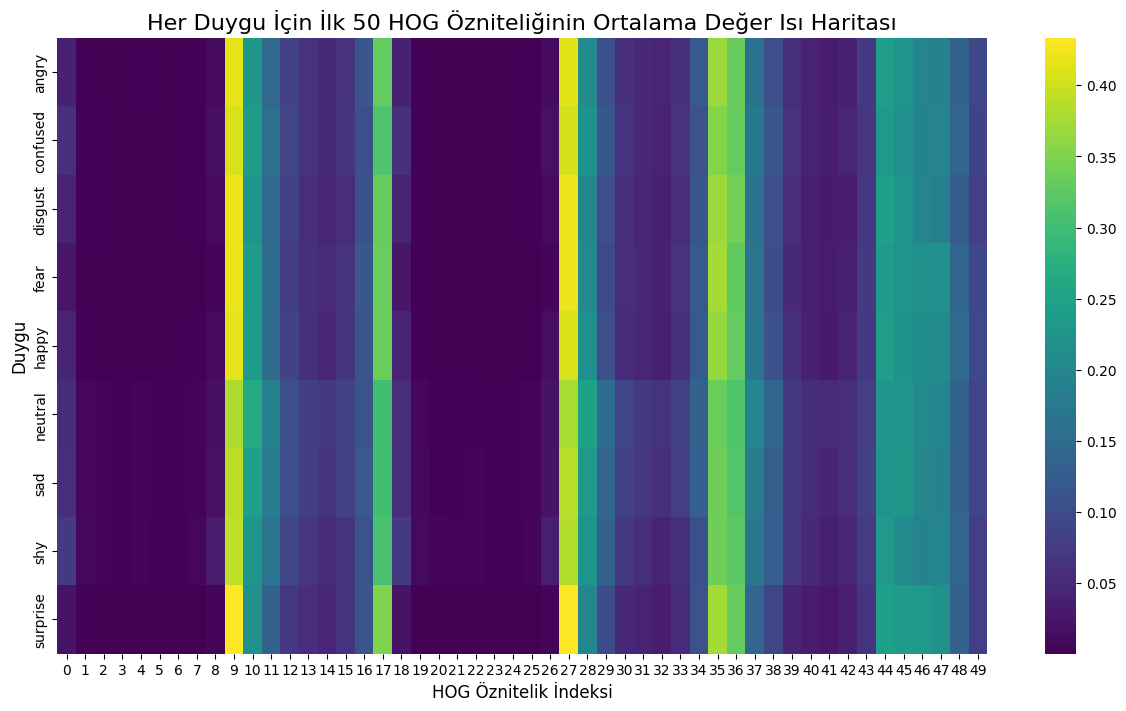


--- C.2. Örnek HOG Özniteliklerinin Değer Dağılımı ---
Seçilen Örnek Özniteliklerin İstatistikleri:
              2589         2008         2281         2522
count  8805.000000  8805.000000  8805.000000  8805.000000
mean      0.137050     0.100770     0.140232     0.155181
std       0.094981     0.111599     0.106935     0.101547
min       0.000000     0.000000     0.000000     0.000000
25%       0.054006     0.009998     0.045921     0.062997
50%       0.120703     0.058732     0.115602     0.143345
75%       0.224273     0.159057     0.236936     0.254125
max       0.420644     0.559213     0.614228     0.445160


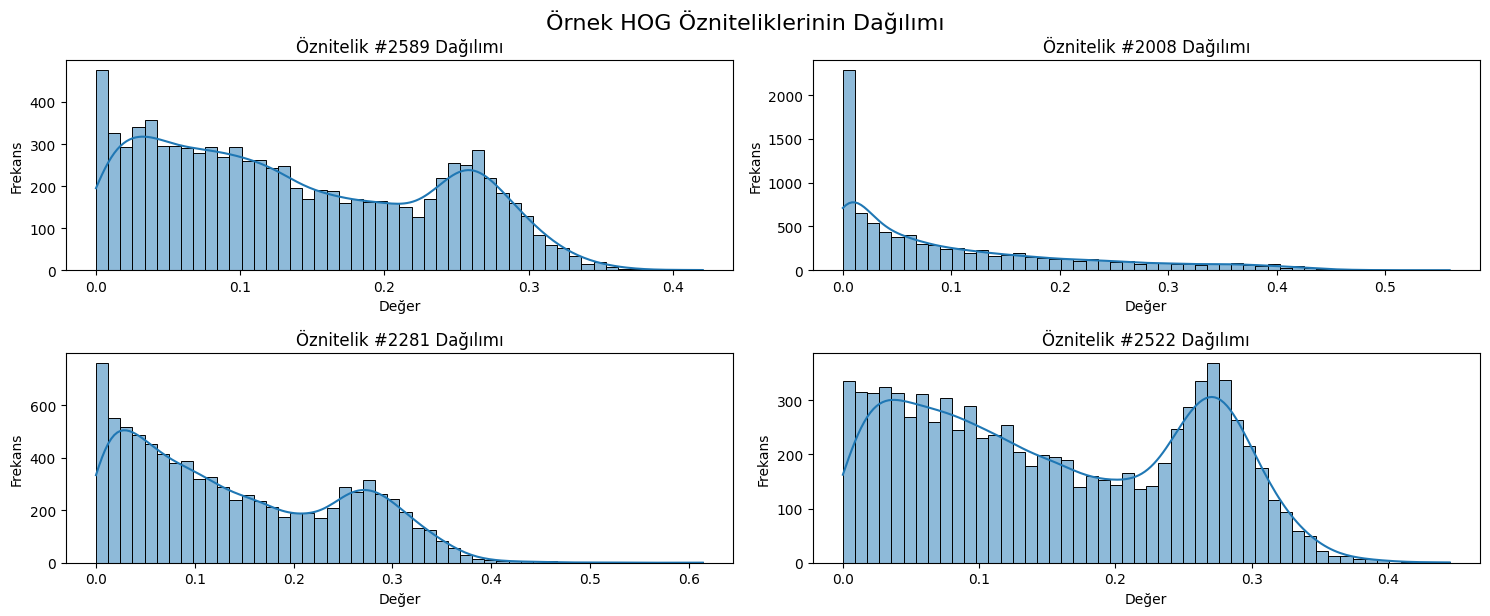


--- C.3. t-SNE ile Gelişmiş Görselleştirme ---
t-SNE için verinin 5000 örneklik bir alt kümesi kullanılıyor...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.031s...
[t-SNE] Computed neighbors for 5000 samples in 1.759s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 16.526821
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.259567
[t-SNE] KL divergence after 300 iterations: 3.170260

Örnek veriler (t-SNE sonrası):
   t-SNE Component 1  t-SNE Component 2   Emotion
0           1.350260          -1.583920     happy
1          -3.928903           1.385607  confused
2          -0.334597           3.020283      fear
3          -1.289546   

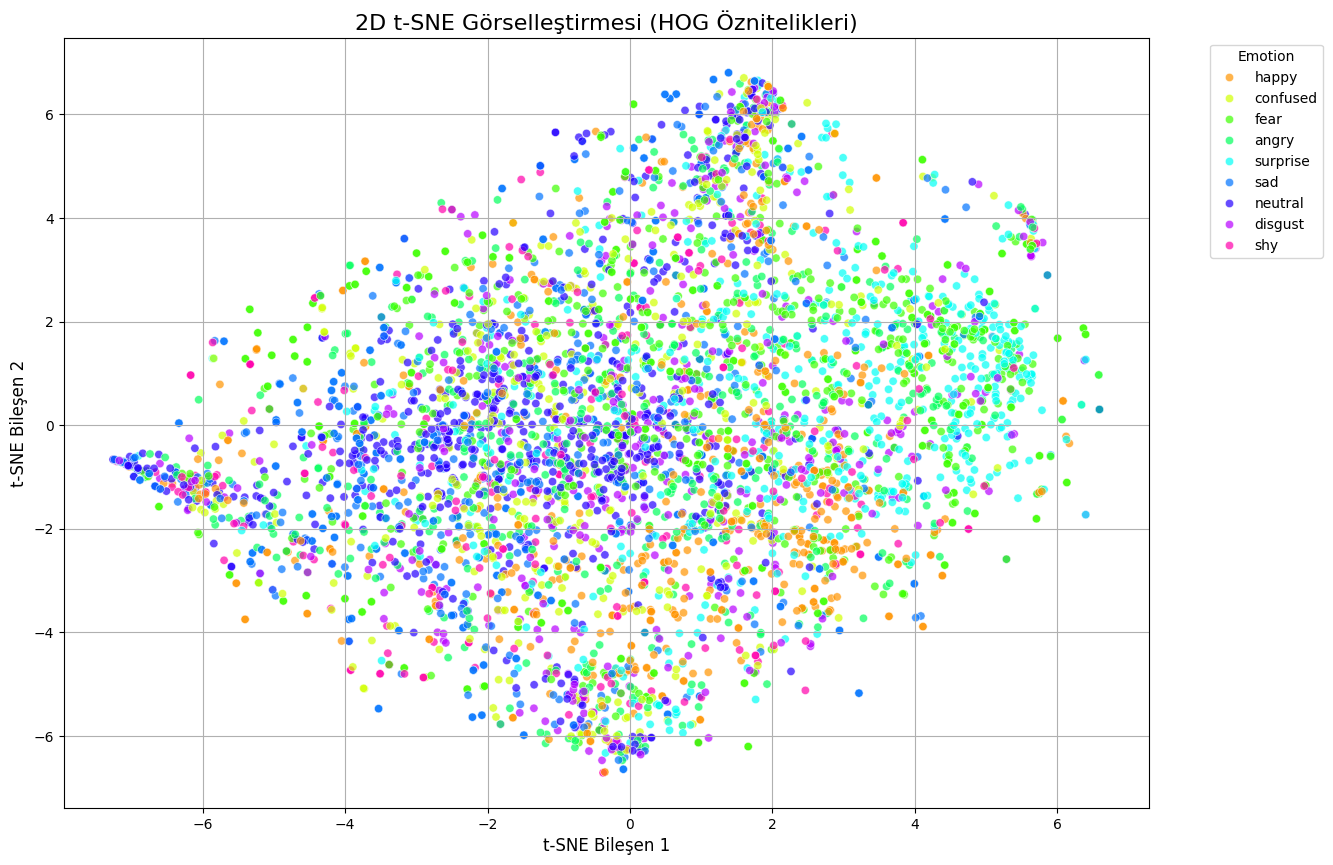


--- Tüm EDA Bölümleri Tamamlandı ---


In [ ]:
# dir Kontrolü 
ORIGINAL_DATASET_PATH = BASE_DIR / "fane_data"
PROCESSED_DATASET_PATH = BASE_DIR / "processed_dataset_gray"

print(f"Orijinal Veri Yolu: {ORIGINAL_DATASET_PATH}")
print(f"İşlenmiş Veri Yolu: {PROCESSED_DATASET_PATH}")

original_exists = ORIGINAL_DATASET_PATH.exists()
processed_exists = PROCESSED_DATASET_PATH.exists()

print(f"Orijinal Yol Mevcut mu? -> {original_exists}")
print(f"İşlenmiş Yol Mevcut mu? -> {processed_exists}")

if not (original_exists and processed_exists):
    print("\nHATA: Gerekli klasörlerden biri veya her ikisi de bulunamadı. Lütfen yolları kontrol edin.")
else:
    # --- 2. Örnek Sınıf ve Dosya Kontrolü ---
    sample_class = 'happy'
    num_samples_to_show = 3

    original_class_path = ORIGINAL_DATASET_PATH / sample_class
    processed_class_path = PROCESSED_DATASET_PATH / sample_class
    
    print(f"\nÖrnek Sınıfın Orijinal Yolu: {original_class_path}")
    print(f"Örnek Sınıfın İşlenmiş Yolu: {processed_class_path}")
    
    if not original_class_path.exists() or not processed_class_path.exists():
        print(f"\nHATA: '{sample_class}' klasörü orijinal veya işlenmiş veri setinde bulunamadı.")
    else:
        # --- 3. Dosya Seçimi ---
        try:
            # Sadece .jpg ve .jpeg dosyalarını ara
            original_files = [f.name for f in original_class_path.glob('*.jp*g')]
            if not original_files:
                raise ValueError("Klasörde hiç .jpg/.jpeg dosyası bulunamadı.")
            
            sample_image_names = np.random.choice(original_files, num_samples_to_show, replace=False)
            print(f"\nBaşarıyla {len(sample_image_names)} adet örnek dosya adı seçildi: {sample_image_names}")
        except ValueError as e:
            print(f"\nHATA: Örnek dosya seçilemedi. Sebep: {e}")
            sample_image_names = []

        # --- 4. Görselleştirme Döngüsü ---
        if len(sample_image_names) > 0:
            fig, axes = plt.subplots(num_samples_to_show, 2, figsize=(9, 4 * num_samples_to_show))
            if num_samples_to_show == 1: axes = np.array([axes])
            fig.suptitle('Ön İşleme Etkisi: Önce vs. Sonra', fontsize=16, y=1.02)

            for i, img_name in enumerate(sample_image_names):
                print("-" * 50)
                print(f"İşleniyor: {img_name}")
                
                # --- "ÖNCE" Resmi İşleme ---
                original_img_path = original_class_path / img_name
                print(f"  -> 'Önce' için aranan yol: {original_img_path}")
                original_img = cv2.imread(str(original_img_path))
                
                if original_img is not None:
                    print("  -> 'Önce' resmi başarıyla okundu.")
                    ax = axes[i, 0]
                    ax.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
                    ax.set_title(f"Önce: {img_name}\nBoyut: {original_img.shape[1]}x{original_img.shape[0]}")
                    ax.axis('off')
                else:
                    print("  -> HATA: 'Önce' resmi okunamadı (cv2.imread None döndürdü).")

                # --- "SONRA" Resmi İşleme ---
                processed_img_path = processed_class_path / Path(img_name).with_suffix('.png')
                print(f"  -> 'Sonra' için aranan yol: {processed_img_path}")
                
                if not processed_img_path.exists():
                    print("  -> HATA: 'Sonra' dosyası bu yolda MEVCUT DEĞİL.")
                else:
                    processed_img = cv2.imread(str(processed_img_path), cv2.IMREAD_GRAYSCALE)
                    if processed_img is not None:
                        print("  -> 'Sonra' resmi başarıyla okundu.")
                        ax = axes[i, 1]
                        ax.imshow(processed_img, cmap='gray')
                        ax.set_title(f"Sonra: İşlenmiş Görüntü\nBoyut: {processed_img.shape[1]}x{processed_img.shape[0]}")
                        ax.axis('off')
                    else:
                        print("  -> HATA: 'Sonra' resmi var ama okunamadı (cv2.imread None döndürdü).")
            
            plt.tight_layout()
            plt.show()


print("\n" + "="*80)
print("BÖLUM B: EDA on HOG Features & Class Labels")
print("="*80)

# --- 1. Class Distribution Analysis ---

print("\n--- B.1. Class Distribution (Training Set) ---")

y_train_series = pd.Series(y_train)
class_counts = y_train_series.value_counts().sort_index()
df_counts = pd.DataFrame(class_counts).reset_index()
df_counts.columns = ['Emotion', 'Count']
class_percentages = y_train_series.value_counts(normalize=True).sort_index() * 100
df_counts['Percentage (%)'] = class_percentages.values.round(2)
print("Class Distribution Table:")
print(df_counts.to_string(index=False))
plt.figure(figsize=(12, 7))
sns.countplot(x=y_train, order=df_counts['Emotion'], palette='viridis')
plt.title('Class Distribution in Training Set', fontsize=16)
plt.ylabel('Number of Samples', fontsize=12)
plt.xlabel('Emotion', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 2. HOG Feature Statistics ---
print("\n--- B.2. HOG Feature Statistics ---")
df_features = pd.DataFrame(X_train)
feature_stats = df_features.describe().T
print("Descriptive Statistics for the first 10 HOG features:")
print(feature_stats.head(10).to_string())
print(f"\nSummary: The full HOG feature set contains {feature_stats.shape[0]} features.")
print(f"The mean value across all features is approximately {feature_stats['mean'].mean():.4f}.")

# --- 3. Feature Separability Visualization with PCA ---
print("\n--- B.3. Visualizing Class Separability with PCA (2 Components) ---")
scaler_eda = StandardScaler()
X_train_scaled = scaler_eda.fit_transform(X_train)
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
df_pca = pd.DataFrame(data=X_train_pca_2d, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Emotion'] = y_train
print("Sample of data after PCA transformation:")
print(df_pca.head().to_string())
plt.figure(figsize=(14, 10))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2',hue='Emotion',palette=sns.color_palette("hsv", len(CLASS_NAMES)),data=df_pca,legend="full",alpha=0.6)
plt.title('2D PCA of HOG Features by Emotion', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# --- 4. Explained Variance by Principal Components ---
print("\n--- B.4. PCA Explained Variance Analysis ---")
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
variance_thresholds = [0.80, 0.90, 0.95, 0.99]
components_needed = [np.argmax(cumulative_variance >= threshold) + 1 for threshold in variance_thresholds]
df_variance = pd.DataFrame({'Variance Explained': [f"{int(v*100)}%" for v in variance_thresholds],'Components Needed': components_needed})
print("Number of PCA components needed to capture variance:")
print(df_variance.to_string(index=False))
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--', markersize=1)
plt.title('Cumulative Explained Variance by PCA Components', fontsize=16)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.90, color='g', linestyle='-.', label='90% Variance')
plt.grid(True)
plt.legend()
plt.show()



print("\n" + "="*80)
print("BÖLÜM C: Derinlemesine EDA: Sınıf Bazında Analiz ve Gelişmiş Görselleştirme")
print("="*80)

from sklearn.manifold import TSNE


print("\n--- C.1. Sınıf Bazında Ortalama Öznitelik Değerleri ---")
df_features_with_labels = pd.concat([df_features, y_train_series.rename('Emotion')], axis=1)
class_feature_means = df_features_with_labels.groupby('Emotion').mean()
print("Her Duygu İçin İlk 5 HOG Özniteliğinin Ortalama Değerleri:")
print(class_feature_means.iloc[:, :5].to_string())
plt.figure(figsize=(15, 8))
sns.heatmap(class_feature_means.iloc[:, :50], cmap='viridis')
plt.title('Her Duygu İçin İlk 50 HOG Özniteliğinin Ortalama Değer Isı Haritası', fontsize=16)
plt.xlabel('HOG Öznitelik İndeksi', fontsize=12)
plt.ylabel('Duygu', fontsize=12)
plt.show()


print("\n--- C.2. Örnek HOG Özniteliklerinin Değer Dağılımı ---")
sample_feature_indices = np.random.choice(df_features.columns, 4, replace=False)
print("Seçilen Örnek Özniteliklerin İstatistikleri:")
print(df_features[sample_feature_indices].describe().to_string())
plt.figure(figsize=(15, 6))
for i, col_idx in enumerate(sample_feature_indices):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_features[col_idx], kde=True, bins=50)
    plt.title(f'Öznitelik #{col_idx} Dağılımı')
    plt.xlabel('Değer')
    plt.ylabel('Frekans')
plt.tight_layout()
plt.suptitle('Örnek HOG Özniteliklerinin Dağılımı', fontsize=16, y=1.02)
plt.show()


print("\n--- C.3. t-SNE ile Gelişmiş Görselleştirme ---")

from sklearn.manifold import TSNE


n_samples_for_tsne = min(len(X_train), 5000) #hızlandırmak için
if n_samples_for_tsne < len(X_train):
    print(f"t-SNE için verinin {n_samples_for_tsne} örneklik bir alt kümesi kullanılıyor...")
    
    _, X_subset, _, y_subset = train_test_split(
        X_train_scaled, y_train, train_size=None, test_size=n_samples_for_tsne,
        stratify=y_train, random_state=42
    )
else:
    print("t-SNE için tam eğitim verisi kullanılıyor...")
    X_subset = X_train_scaled
    y_subset = y_train

#hızlı görselleştirme için 300 iterasyon seçildi
tsne = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300, random_state=42)
X_tsne_2d = tsne.fit_transform(X_subset)


df_tsne = pd.DataFrame(data=X_tsne_2d, columns=['t-SNE Component 1', 't-SNE Component 2'])
df_tsne['Emotion'] = y_subset


print("\nÖrnek veriler (t-SNE sonrası):")
print(df_tsne.head().to_string())

# Görselleştirme
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='t-SNE Component 1', y='t-SNE Component 2',
    hue='Emotion',
    palette=sns.color_palette("hsv", len(CLASS_NAMES)),
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('2D t-SNE Görselleştirmesi (HOG Öznitelikleri)', fontsize=16)
plt.xlabel('t-SNE Bileşen 1', fontsize=12)
plt.ylabel('t-SNE Bileşen 2', fontsize=12)
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

print("\n--- Tüm EDA Bölümleri Tamamlandı ---")

### StandartScaler ve PCA



In [ ]:


print("\n" + "="*80)
print("Veriyi Modellemeye Hazırlama: StandardScaler ve PCA Uygulaması")
print("="*80)

# --- 1. StandardScaler'ı Kurma ve Uygulama ---
# Scaler'ı sadece eğitim verisi üzerinde 'fit' ederiz.
# Bu, eğitim verisinin ortalama ve standart sapmasını öğrenmesini sağlar.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Test verisini, eğitim verisinden öğrenilmiş olan aynı ölçekleyici ile 'transform' ederiz.
# Test verisi üzerinde asla 'fit' yapmayız!
X_test_scaled = scaler.transform(X_test)

print("StandardScaler uygulandı.")
print(f"Orijinal X_train ortalaması (ilk öznitelik): {X_train[:, 0].mean():.4f}")
print(f"Ölçeklenmiş X_train_scaled ortalaması (ilk öznitelik): {X_train_scaled[:, 0].mean():.4f}")


# --- 2. PCA'i Kurma ve Uygulama ---
# PCA'e, verideki toplam varyansın %95'ini korumasını söylüyoruz.
# Bu, bileşen sayısını manuel olarak seçmekten daha iyi bir yöntemdir.
pca = PCA(n_components=0.95, random_state=42)

# PCA'i de sadece ölçeklenmiş eğitim verisi üzerinde 'fit' ederiz.
X_train_pca = pca.fit_transform(X_train_scaled)

# Test verisini de aynı PCA modeliyle dönüştürürüz.
X_test_pca = pca.transform(X_test_scaled)

print("\nPCA uygulandı.")
print(f"Orijinal öznitelik sayısı: {X_train_scaled.shape[1]}")
print(f"PCA sonrası öznitelik sayısı (Varyansın %95'ini koruyan): {pca.n_components_}")
print(f"Eğitim verisinin yeni boyutu: {X_train_pca.shape}")
print(f"Test verisinin yeni boyutu: {X_test_pca.shape}")

print("\n--- Veri Hazırlığı Tamamlandı ---")
print("Modelleme için kullanılacak yeni değişkenler:")
print("X_train_pca, y_train, X_test_pca, y_test")


Veriyi Modellemeye Hazırlama: StandardScaler ve PCA Uygulaması
StandardScaler uygulandı.
Orijinal X_train ortalaması (ilk öznitelik): 0.0100
Ölçeklenmiş X_train_scaled ortalaması (ilk öznitelik): -0.0000

PCA uygulandı.
Orijinal öznitelik sayısı: 8100
PCA sonrası öznitelik sayısı (Varyansın %95'ini koruyan): 1582
Eğitim verisinin yeni boyutu: (8805, 1582)
Test verisinin yeni boyutu: (2935, 1582)

--- Veri Hazırlığı Tamamlandı ---
Modelleme için kullanılacak yeni değişkenler:
X_train_pca, y_train, X_test_pca, y_test


# Model Eğitimleri

### 1. SVM

In [ ]:


print("\n" + "="*80)
print("Model 1: Support Vector Machine (SVM) - Optimizasyon")
print("="*80)


svm_model = SVC(probability=True, random_state=42)


param_grid_svm = {
    'C': [1, 10, 100, 1000],          # Ceza parametresi: Modelin ne kadar esnek olacağını belirler.
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001] # Kernel katsayısı: Tek bir noktanın etkisinin ne kadar uzağa yayılacağını belirler.
}

# GridSearchCV'yi kur
search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    scoring='accuracy',
    cv=5,          # 5-katlı çapraz doğrulama
    n_jobs=-1,     # Mümkün olan tüm işlemci çekirdeklerini kullan
    verbose=2      # Arama sırasında detaylı bilgi ver
)

print("GridSearchCV araması başlıyor. Bu işlem PCA'li veri üzerinde daha hızlı olacaktır...")
print("Test edilecek parametre kombinasyonları:")
for c_val in param_grid_svm['C']:
    for gamma_val in param_grid_svm['gamma']:
        print(f"  - C={c_val}, gamma={gamma_val}")

# Aramayı Başlat
# DİKKAT: Modeli, PCA'den geçmiş olan 'X_train_pca' verisi ile eğitiyoruz.
search_svm.fit(X_train_pca, y_train)

# En İyi Sonuçları Yazdır
print("\nSVM için GridSearchCV Tamamlandı!")
print("-" * 50)
print(f"En İyi Parametreler: {search_svm.best_params_}")
print(f"Bu parametrelerle elde edilen en iyi çapraz doğrulama skoru (Accuracy): {search_svm.best_score_:.4f}")
print("-" * 50)

# En iyi modeli daha sonra DEĞERLENDİRME adımında kullanmak üzere bir değişkene kaydet
best_svm_model = search_svm.best_estimator_

print("\nEn iyi SVM modeli 'best_svm_model' değişkenine kaydedildi.")
print("Bir sonraki adım, bu modeli test seti üzerinde değerlendirmek olacak.")


Model 1: Support Vector Machine (SVM) - Optimizasyon
GridSearchCV araması başlıyor. Bu işlem PCA'li veri üzerinde daha hızlı olacaktır...
Test edilecek parametre kombinasyonları:
  - C=1, gamma=scale
  - C=1, gamma=auto
  - C=1, gamma=0.1
  - C=1, gamma=0.01
  - C=1, gamma=0.001
  - C=10, gamma=scale
  - C=10, gamma=auto
  - C=10, gamma=0.1
  - C=10, gamma=0.01
  - C=10, gamma=0.001
  - C=100, gamma=scale
  - C=100, gamma=auto
  - C=100, gamma=0.1
  - C=100, gamma=0.01
  - C=100, gamma=0.001
  - C=1000, gamma=scale
  - C=1000, gamma=auto
  - C=1000, gamma=0.1
  - C=1000, gamma=0.01
  - C=1000, gamma=0.001
Fitting 5 folds for each of 20 candidates, totalling 100 fits

SVM için GridSearchCV Tamamlandı!
--------------------------------------------------
En İyi Parametreler: {'C': 10, 'gamma': 'scale'}
Bu parametrelerle elde edilen en iyi çapraz doğrulama skoru (Accuracy): 0.5564
--------------------------------------------------

En iyi SVM modeli 'best_svm_model' değişkenine kaydedildi.

In [ ]:
import joblib

print("\n--- Kaydedilmiş Modeller Disketen Geri Yükleniyor ---")

try:
    best_svm_model = joblib.load('best_svm_model.joblib')
    print("-> SVM modeli başarıyla yüklendi.")
except FileNotFoundError:
    print("-> HATA: 'best_svm_model.joblib' dosyası bulunamadı.")

try:
    best_rf_model = joblib.load('best_rf_model.joblib')
    print("-> Random Forest modeli başarıyla yüklendi.")
except FileNotFoundError:
    print("-> HATA: 'best_rf_model.joblib' dosyası bulunamadı.")
    
# (Aynı işlemi XGBoost için de yapacaksın)
try:
    best_xgb_model = joblib.load('best_xgb_model.joblib')
    print("-> XGBoost modeli başarıyla yüklendi.")
except FileNotFoundError:
    print("-> HATA: 'best_xgb_model.joblib' dosyası bulunamadı.")

# Şimdi bu değişkenlerle değerlendirme kodunu çalıştırabilirsin

### 2. MLP

In [ ]:


def train_mlp_final_solution():
    print("\n" + "="*80)
    print("Nihai Çözüm: Aykırı Değerleri Kırpma ve Kararlı MLP Eğitimi")
    print("="*80)

    # --- Adım 1: Aşırı Aykırı Değerleri Manuel Olarak Kırpma (Clipping) ---
    print("--- Adım 1: Aşırı aykırı değerler tespit ediliyor ve kırpılıyor... ---")
    
    # Tüm eğitim verisindeki 99.9'uncu persentil değerini bulalım.
    # Bu, verinin büyük çoğunluğunu kapsayan makul bir üst limit olacaktır.
    p999 = np.percentile(X_train, 99.9)
    print(f"Verinin %99.9'u {p999:.4f} değerinin altında. Bu değer üst limit olarak kullanılacak.")

    # X_train ve X_test'teki bu limitin üzerindeki tüm değerleri bu limitle değiştir.
    X_train_clipped = np.clip(X_train, a_min=None, a_max=p999)
    X_test_clipped = np.clip(X_test, a_min=None, a_max=p999)

    print(f"Kırpma öncesi X_train max değer: {X_train.max():.4f}")
    print(f"Kırpma sonrası X_train_clipped max değer: {X_train_clipped.max():.4f}")
    print("Aykırı değer temizliği tamamlandı.")

    # --- Adım 2: Temizlenmiş Veri Üzerinde Model Eğitimi ---
    print("\n--- Adım 2: Temizlenmiş veri üzerinde MLP optimizasyonu başlıyor ---")
    
    # Artık standart pipeline'ımızı güvenle kullanabiliriz.
    pipe_mlp = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('mlp', MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=15, random_state=42))
    ])

    param_grid_mlp = {
        'pca__n_components': [150, 200],
        'mlp__hidden_layer_sizes': [(100,), (100, 50)],
        'mlp__activation': ['relu', 'tanh'],
        'mlp__alpha': [0.001, 0.01],
    }

    search_mlp = GridSearchCV(
        estimator=pipe_mlp,
        param_grid=param_grid_mlp,
        scoring='accuracy',
        cv=3,
        verbose=2
    )

    start_time = time.time()
    
    # DİKKAT: Eğitimi, kırpılmış olan 'X_train_clipped' verisi ile yapıyoruz.
    search_mlp.fit(X_train_clipped, y_train)

    end_time = time.time()
    total_duration_minutes = (end_time - start_time) / 60

    print("\nMLP için GridSearchCV Tamamlandı!")
    print("-" * 50)
    print(f"TOPLAM EĞİTİM SÜRESİ: {total_duration_minutes:.2f} dakika")
    print(f"En İyi Parametreler: {search_mlp.best_params_}")
    print(f"En iyi skor: {search_mlp.best_score_:.4f}")
    print("-" * 50)
    
    global best_mlp_model
    best_mlp_model = search_mlp.best_estimator_
    print("\nEn iyi MLP modeli 'best_mlp_model' değişkenine kaydedildi.")

if __name__ == '__main__':
    try:
        if 'X_train' in locals() and X_train.size > 0:
             train_mlp_final_solution()
             print("\n\n--- MLP Eğitim Süreci Başarıyla Tamamlandı ---")
        else:
            print("HATA: Eğitim verisi (X_train) bulunamadı.")
    except Exception as e:
        print(f"Beklenmedik bir hata oluştu: {e}")


Nihai Çözüm: Aykırı Değerleri Kırpma ve Kararlı MLP Eğitimi
--- Adım 1: Aşırı aykırı değerler tespit ediliyor ve kırpılıyor... ---
Verinin %99.9'u 0.7071 değerinin altında. Bu değer üst limit olarak kullanılacak.
Kırpma öncesi X_train max değer: 1.0000
Kırpma sonrası X_train_clipped max değer: 0.7071
Aykırı değer temizliği tamamlandı.

--- Adım 2: Temizlenmiş veri üzerinde MLP optimizasyonu başlıyor ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(100,), pca__n_components=150; total time=   4.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(100,), pca__n_components=150; total time=   3.6s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(100,), pca__n_components=150; total time=   3.5s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(100,), pca__n_components=200; total time=   5.0s
[CV] END mlp__activation=relu, mlp__alp

### 3. Random Forest

In [ ]:



print("\n" + "="*80)
print("Model 3: Random Forest - Optimizasyon (PCA Verisi İle)")
print("="*80)


rf_model = RandomForestClassifier(random_state=42)


param_grid_rf = {
    'n_estimators': [100, 200, 300],    # Ormandaki ağaç sayısı
    'max_depth': [10, 20, None],        # Her bir ağacın maksimum derinliği
    'min_samples_leaf': [1, 2, 4],      # Bir yaprakta olması gereken minimum örnek
    'max_features': ['sqrt', 'log2']    # Her bölmede denenecek öznitelik sayısı
}

# 3. GridSearchCV'yi Kur
# Paralel çalışmanın şimdi sorunsuz çalışması gerekiyor.
search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=3,
    n_jobs=-1, # Paralel çalışmayı etkinleştir
    verbose=2
)

print("GridSearchCV araması Random Forest için başlıyor (Küçültülmüş PCA verisi üzerinde)...")

# 4. Aramayı Başlat
start_time = time.time()
# DİKKAT: Doğrudan, boyutu küçültülmüş olan 'X_train_pca' verisini kullanıyoruz.
search_rf.fit(X_train_pca, y_train)
end_time = time.time()
total_duration_minutes = (end_time - start_time) / 60

# 5. En İyi Sonuçları Yazdır
print("\nRandom Forest için GridSearchCV Tamamlandı!")
print("-" * 50)
print(f"TOPLAM EĞİTİM SÜRESİ: {total_duration_minutes:.2f} dakika")
print(f"En İyi Parametreler: {search_rf.best_params_}")
print(f"Bu parametrelerle elde edilen en iyi çapraz doğrulama skoru (Accuracy): {search_rf.best_score_:.4f}")
print("-" * 50)

# En iyi modeli kaydet
global best_rf_model
best_rf_model = search_rf.best_estimator_
print("\nEn iyi Random Forest modeli 'best_rf_model' değişkenine kaydedildi.")


Model 3: Random Forest - Optimizasyon (PCA Verisi İle)
GridSearchCV araması Random Forest için başlıyor (Küçültülmüş PCA verisi üzerinde)...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Random Forest için GridSearchCV Tamamlandı!
--------------------------------------------------
TOPLAM EĞİTİM SÜRESİ: 13.74 dakika
En İyi Parametreler: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Bu parametrelerle elde edilen en iyi çapraz doğrulama skoru (Accuracy): 0.4152
--------------------------------------------------

En iyi Random Forest modeli 'best_rf_model' değişkenine kaydedildi.


### 4. Gradient Boosting

In [ ]:

print("\n--- Etiketler Sayısallaştırılıyor (Label Encoding) ---")

# LabelEncoder'ı oluştur
le = LabelEncoder()

# Encoder'ı eğitim verisine "öğret" ve hem eğitim hem de test verisini dönüştür.
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Sınıf isimlerini daha sonra raporlama için saklayalım
# le.classes_ bize doğru sıralamayı verir ('angry' -> 0, 'confused' -> 1, ...)
CLASS_NAMES_ENCODED = le.classes_

# Hangi sınıfın hangi sayıya dönüştüğünü görelim
print("Etiket Dönüşüm Haritası:")
for i, class_name in enumerate(CLASS_NAMES_ENCODED):
    print(f"  '{class_name}' -> {i}")
    
print(f"\nOrijinal y_train örneği: {y_train[:5]}")
print(f"Dönüştürülmüş y_train_encoded örneği: {y_train_encoded[:5]}")


print("\n" + "="*80)
print("Model 4: Gradient Boosting (XGBoost) - Optimizasyon (Sayısal Etiketlerle)")
print("="*80)

# 1. Modeli Tanımla
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# 2. Test Edilecek Hiperparametreler Menüsü
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# 3. GridSearchCV'yi Kur
search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("\nGridSearchCV araması XGBoost için başlıyor")

# 4. Aramayı Başlat
start_time = time.time()
# DİKKAT: Artık sayısal olan 'y_train_encoded' etiketlerini kullanıyoruz.
search_xgb.fit(X_train_pca, y_train_encoded)
end_time = time.time()
total_duration_minutes = (end_time - start_time) / 60

# 5. En İyi Sonuçları Yazdır
print("\nXGBoost için GridSearchCV Tamamlandı!")
print("-" * 50)
print(f"TOPLAM EĞİTİM SÜRESİ: {total_duration_minutes:.2f} dakika")
print(f"En İyi Parametreler: {search_xgb.best_params_}")
print(f"Bu parametrelerle elde edilen en iyi çapraz doğrulama skoru (Accuracy): {search_xgb.best_score_:.4f}")
print("-" * 50)

# En iyi modeli kaydet
global best_xgb_model
best_xgb_model = search_xgb.best_estimator_
print("\nEn iyi XGBoost modeli 'best_xgb_model' değişkenine kaydedildi.")
print("\nTüm modellerin eğitimi ve optimizasyonu tamamlandı!")


--- Etiketler Sayısallaştırılıyor (Label Encoding) ---
Etiket Dönüşüm Haritası:
  'angry' -> 0
  'confused' -> 1
  'disgust' -> 2
  'fear' -> 3
  'happy' -> 4
  'neutral' -> 5
  'sad' -> 6
  'shy' -> 7
  'surprise' -> 8

Orijinal y_train örneği: ['happy' 'neutral' 'shy' 'happy' 'shy']
Dönüştürülmüş y_train_encoded örneği: [4 5 7 4 7]

Model 4: Gradient Boosting (XGBoost) - Optimizasyon (Sayısal Etiketlerle)

GridSearchCV araması XGBoost için başlıyor (Küçültülmüş PCA verisi üzerinde)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
